Importing Libraries & Reproducibility

In [13]:
# ------------------- Importing Libraries & Reproducibility -------------------
import pandas as pd
import numpy as np
import os, random
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.optimizers import Adam
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt

# Reproducibility
os.environ["PYTHONHASHSEED"] = "0"
os.environ["TF_DETERMINISTIC_OPS"] = "1"       
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"       
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

random.seed(42)
np.random.seed(42)
tf.keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


Loading the Dataset

In [14]:
# ------------------- Loading the Dataset -------------------
train_df = pd.read_csv(r"C:\Users\tassn\Downloads\ensamble\train.csv")
val_df   = pd.read_csv(r"C:\Users\tassn\Downloads\ensamble\val.csv")
test_df  = pd.read_csv(r"C:\Users\tassn\Downloads\ensamble\test.csv")


Preprocessing & CNN Feature Preparation

In [15]:
# ------------------- Preprocessing & CNN Feature Preparation -------------------
P_COLS = [f"p{i}" for i in range(1, 43)]

def build_cnn_features(df):
    boards = df[P_COLS].to_numpy(dtype=np.int8).reshape(-1, 6, 7)
    turns  = df["turn"].to_numpy(dtype=np.int8).reshape(-1, 1, 1)
    boards = boards * turns
    cur = (boards == 1).astype(np.float32)
    opp = (boards == -1).astype(np.float32)
    X = np.stack([cur, opp], axis=-1)
    y = None
    if "label_move_col" in df.columns:
        y = df["label_move_col"].to_numpy(dtype=np.int64)
    return X, y

X_train, y_train = build_cnn_features(train_df)
X_val,   y_val   = build_cnn_features(val_df)
X_test,  _       = build_cnn_features(test_df)


The history saving thread hit an unexpected error (OperationalError('database or disk is full')).History will not be written to the database.


CNN Model Design

In [16]:
# ------------------- CNN Model Design -------------------
num_classes = 7
lambdaa = 5e-5
drop = 0.20
lr = 1e-3

y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_val_oh   = keras.utils.to_categorical(y_val, num_classes)

model = keras.Sequential([
    layers.Input(shape=(6, 7, 2)),
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(lambdaa)),
    layers.Dropout(drop),
    layers.Dense(num_classes),
    layers.Softmax(name="policy")
])

opt = Adam(learning_rate=lr)
loss = keras.losses.CategoricalCrossentropy(label_smoothing=0.02)
model.compile(optimizer=opt, loss=loss, metrics=['accuracy'])
model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 6, 7, 64)       │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 6, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 6, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 6, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 6, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 6, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 6, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_10 (ReLU)                 │ (None, 6, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           903 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ policy (Softmax)                │ (None, 7)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,063 (332.28 KB)

 Trainable params: 84,679 (330.78 KB)

 Non-trainable params: 384 (1.50 KB)

Training the CNN

In [17]:
# ------------------- Training the CNN -------------------
callbacks = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=70,
    batch_size=512,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 100ms/step - accuracy: 0.3656 - loss: 1.7104 - val_accuracy: 0.3674 - val_loss: 1.8106 - learning_rate: 0.0010
Epoch 2/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.4383 - loss: 1.5318 - val_accuracy: 0.3674 - val_loss: 2.0163 - learning_rate: 0.0010
Epoch 3/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.5111 - loss: 1.3658 - val_accuracy: 0.3674 - val_loss: 2.6063 - learning_rate: 0.0010
Epoch 4/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 87ms/step - accuracy: 0.5498 - loss: 1.2776 - val_accuracy: 0.3684 - val_loss: 2.5461 - learning_rate: 0.0010
Epoch 5/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - accuracy: 0.5728 - loss: 1.2192 - val_accuracy: 0.4139 - val_loss: 1.8869 - learning_rate: 0.0010
Epoch 6/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 0.5904 - loss: 1.1759 - val_accuracy: 0.4906 - val_loss: 1.4882 - learning_rate: 0.0010
Epoch 7/70
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - accuracy: 0.6039 - loss: 1.1417 - val_a

Extract CNN Features for XGBoost

In [23]:
# ------------------- CNN Feature Extraction -------------------
cnn_output_train = model.predict(X_train)
cnn_output_val   = model.predict(X_val)
cnn_output_test  = model.predict(X_test)

cnn_output_train = cnn_output_train.reshape(cnn_output_train.shape[0], -1)
cnn_output_val   = cnn_output_val.reshape(cnn_output_val.shape[0], -1)
cnn_output_test  = cnn_output_test.reshape(cnn_output_test.shape[0], -1)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step
337/337 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step  
340/340 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


XGBoost Training & Evaluation

Train Accuracy: 0.7672074090372653
Validation Accuracy: 0.5998700575459439


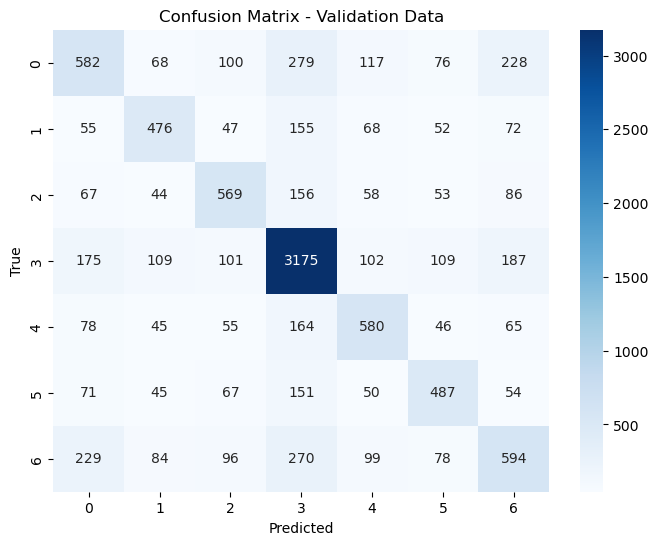

In [24]:
# ------------------- XGBoost Training & Evaluation -------------------
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(cnn_output_train, y_train)

train_pred = xgb.predict(cnn_output_train)
val_pred   = xgb.predict(cnn_output_val)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Validation Accuracy:", accuracy_score(y_val, val_pred))

cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Validation Data")
plt.show()


Save Test Predictions

In [26]:
# ------------------- Save Test Predictions -------------------
y_test_pred = xgb.predict(cnn_output_test)
Prediction = pd.DataFrame({
    "id": range(1, len(y_test_pred) + 1),
    "label_move_col": y_test_pred
})

Prediction.to_csv(r"C:\Users\tassn\Downloads\ensamble\CNN_XGB_prediction.csv", index=False)